In [1]:
import os

import coiled
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from frisky import hijack

from srm.downscaling_utils import interpolate_coarse_to_fine_grid
from srm.qa_flags import (
    DIR_QA_FLAG_CONSTANT_INPUTS,
    calculate_thresholds,
    discover_leaves,
    flag_global_exceedances,
    flag_outliers,
    flag_rsds_above_max,
    get_data,
    parse_tag,
    plot_flags,
    run_flag_loop,
    write_individual_flags,
)
from srm.qaqc import calculate_distortion_flags, sign_flip_mask

os.environ["FRISKY_SUMMARY"] = "off"

# A. Define what data arrays exist to traverse

In [2]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [3]:
GCMS = ["CESM2-WACCM"]

# BRANCH = "v0.13.0"
# ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
# STORE_SUBSET_ID = "global"

BRANCH = "pr-638-global"
ROOT_DIR = "s3://carbonplan-srm/scratch/output/qa/"
STORE_SUBSET_ID = "global"

In [4]:
PLOT_FLAG_MAPS = True
BUCKET = "carbonplan-srm"
PREFIX = "scratch/output/qa-intermediate-flags-v2"

## Set up cluster

In [5]:
cluster = coiled.Cluster(
    name="srm-qaqc-flags-nrh",
    region="us-west-2",
    n_workers=12,
    worker_vm_types=["m8gn.xlarge"],
    scheduler_vm_types="c8g.xlarge",
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags={"Project": "SRM"},
    worker_options={"nthreads": 8},
    environ={"ZARR_ASYNC__CONCURRENCY": "128"},
)

client = hijack(cluster.get_client())
client

[2026-09-06 13:15:36,096][INFO    ][coiled] Fetching latest package priorities...
[2026-09-06 13:15:36,097][INFO    ][coiled.package_sync] Resolving your local /Users/clairezarakas/Documents/science/srm-downscaling/uv.lock Python environment...
[2026-09-06 13:15:36,291][INFO    ][coiled.package_sync] Scanning 293 python packages...
[2026-09-06 13:15:36,498][INFO    ][coiled] Running pip check...
[2026-09-06 13:15:36,770][INFO    ][coiled] Validating environment...
[2026-09-06 13:15:37,583][INFO    ][coiled] Creating wheel for ~/Documents/science/srm-downscaling/src...
[2026-09-06 13:15:37,677][INFO    ][coiled] Creating wheel for srm...
[2026-09-06 13:15:39,364][INFO    ][coiled] Uploading coiled_local_src...
[2026-09-06 13:15:40,557][INFO    ][coiled] Uploading srm...
[2026-09-06 13:15:41,410][INFO    ][coiled] Creating software environment...
[2026-09-06 13:15:42,397][INFO    ][coiled] Creating Cluster (name: srm-qaqc-flags-nrh, https://cloud.coiled.io/clusters/2014143 ). This usuall

<frisky.Client: scheduler="wss://cluster-tdfgj.dask.host/spWatCVYPtmG0GIP/frisky-comm?__frisky_dial_host=54.218.82.47" id="client-0">

In [6]:
[
    trees,
    tags,
    gcms_np,
    scenarios_np,
    variables_np,
    tags_np,
    methods_np,
    debiased_coarse_flags_np,
] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID, is_downscaled=True
)

opened 1/1 stores on branch 'pr-638-global': CESM2-WACCM
196 leaves across 1 GCMs


/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1291: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1291: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


In [6]:
from srm.qa_flags import run_step2

Discovering leaves of the data tree...


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:1252: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:1252: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


opened 1/1 stores on branch 'pr-638-global': CESM2-WACCM
196 leaves across 1 GCMs
  leaf discovery completed in 76.2s
Calculating flags on coarse debiased data...
Running flag loop 1/5: global exceedance flag...
71
CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_rsds_g6_1p5k_001_qdmsd


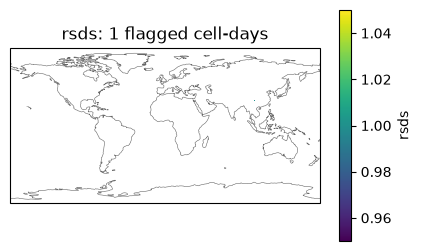

CESM2-WACCM_rsds_g6_1p5k_002_qdmsd


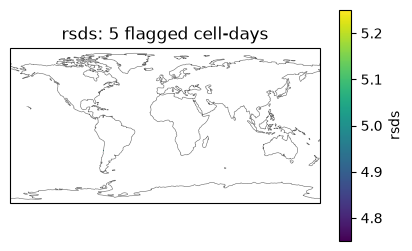

CESM2-WACCM_rsds_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_rsds_historical_r1i1p1f1_qdmsd
No flags found.
CESM2-WACCM_rsds_historical_r2i1p1f1_qdmsd
No flags found.
CESM2-WACCM_rsds_historical_r3i1p1f1_qdmsd
No flags found.
CESM2-WACCM_pr_historical_r1i1p1f1_qdmsd
No flags found.
CESM2-WACCM_pr_historical_r3i1p1f1_qdmsd
No flags found.
CESM2-WACCM_pr_historical_r2i1p1f1_qdmsd
No flags found.
CESM2-WACCM_tas_historical_r1i1p1f1_qdmsd
No flags found.
CESM2-WACCM_tas_historical_r3i1p1f1_qdmsd
No flags found.
CESM2-WACCM_tas_h

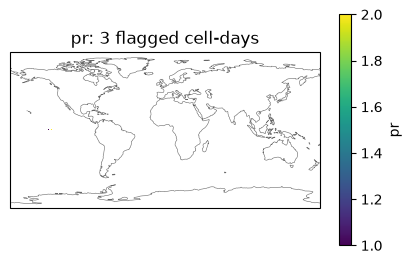

CESM2-WACCM_pr_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_009_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_003_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_005_qdmsd


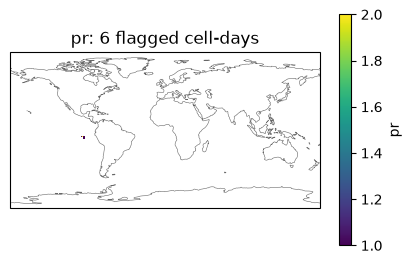

CESM2-WACCM_pr_ssp245_002_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_001_qdmsd


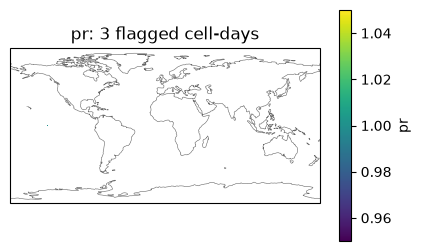

CESM2-WACCM_tas_ssp245_001_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_002_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_004_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_003_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_009_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_005_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_009_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_tasmin_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_tasmin_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_tasmin_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_tasmin_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_tasmin_ssp245_009_qdmsd
No fla

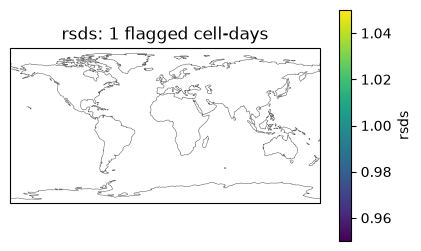

CESM2-WACCM_rsds_ssp245_004_qdmsd


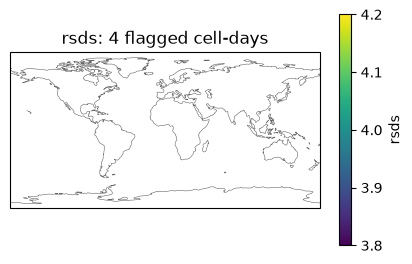

CESM2-WACCM_rsds_ssp245_001_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_002_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_005_qdmsd


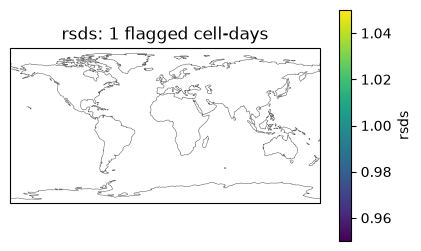

CESM2-WACCM_rsds_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_003_qdmsd
No flags found.
  flag loop 1/5 completed in 359.2s
Running flag loop 2/5: temperature inconsistency flag...
71
CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd


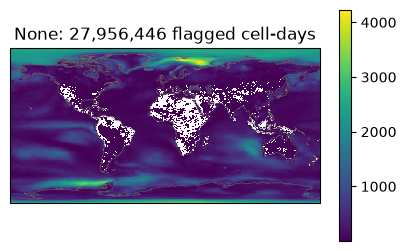

CESM2-WACCM_tas_g6_1p5k_001_qdmsd


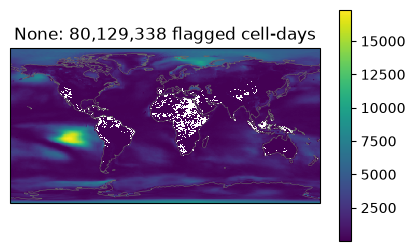

CESM2-WACCM_tas_g6_1p5k_002_qdmsd


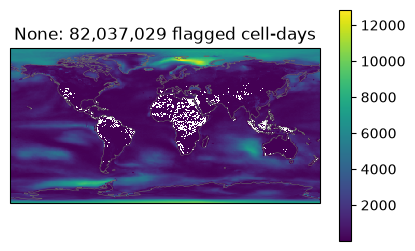

CESM2-WACCM_tas_g6_1p5k_003_qdmsd


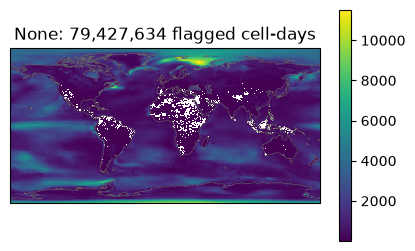

CESM2-WACCM_tas_ssp245_009_qdmsd


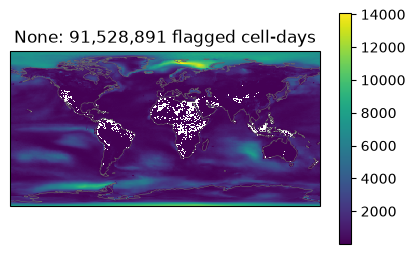

CESM2-WACCM_tas_ssp245_006_qdmsd


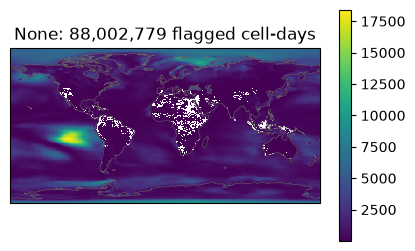

CESM2-WACCM_tas_ssp245_010_qdmsd


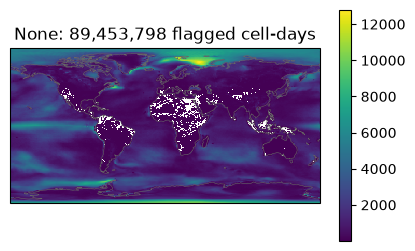

CESM2-WACCM_tas_ssp245_007_qdmsd


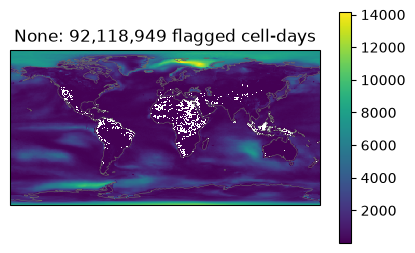

CESM2-WACCM_tas_ssp245_008_qdmsd


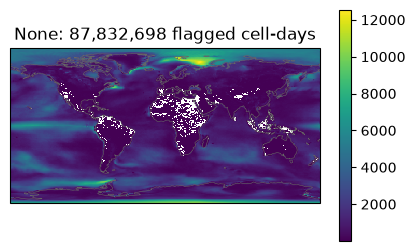

  flag loop 2/5 completed in 169.2s
Running flag loop 3/5: annual outlier flag...
71
CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd


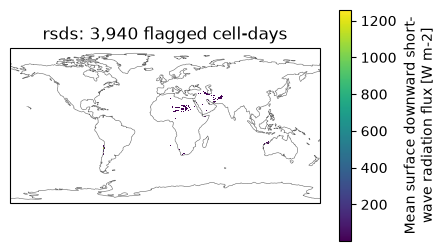

CESM2-WACCM_tasmin_g6_1p5k_end_002_qdmsd


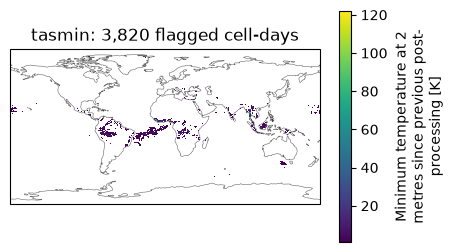

CESM2-WACCM_pr_g6_1p5k_end_002_qdmsd


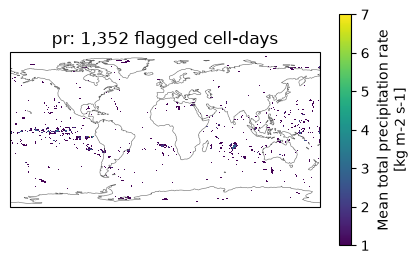

CESM2-WACCM_tasmax_g6_1p5k_end_002_qdmsd


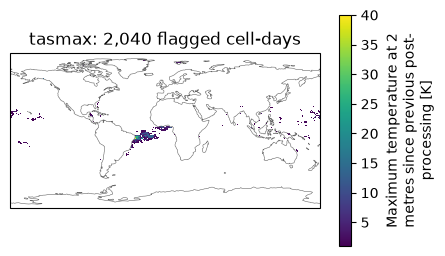

CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd


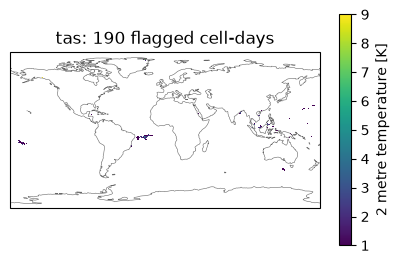

CESM2-WACCM_pr_g6_1p5k_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


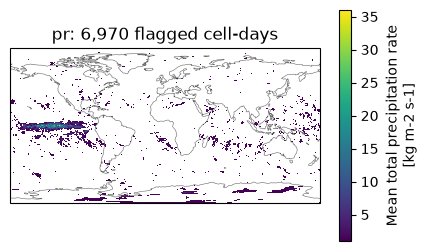

CESM2-WACCM_pr_g6_1p5k_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


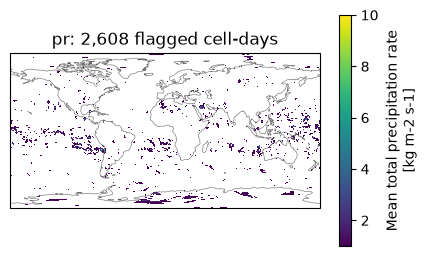

CESM2-WACCM_pr_g6_1p5k_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


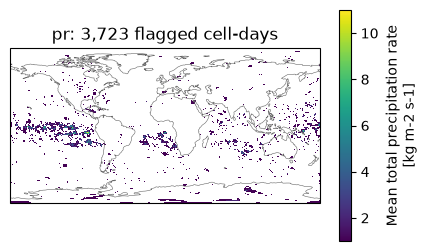

CESM2-WACCM_rsds_g6_1p5k_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


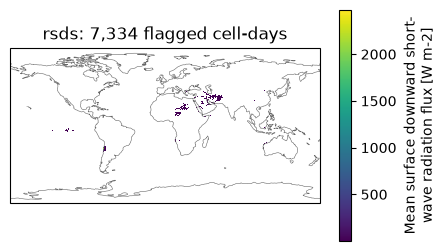

CESM2-WACCM_rsds_g6_1p5k_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


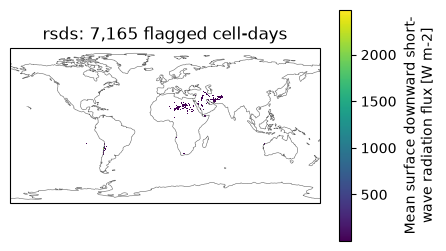

CESM2-WACCM_rsds_g6_1p5k_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


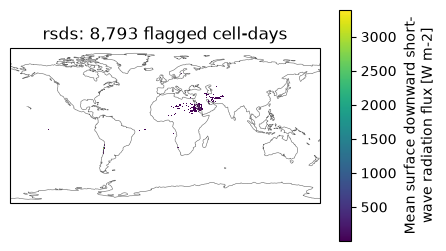

CESM2-WACCM_tas_g6_1p5k_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


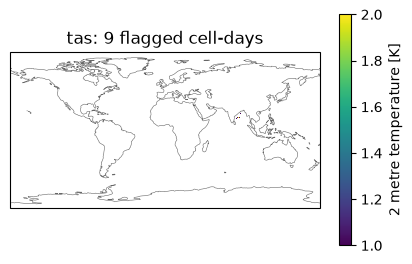

CESM2-WACCM_tas_g6_1p5k_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


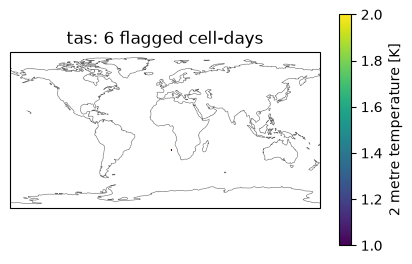

CESM2-WACCM_tas_g6_1p5k_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


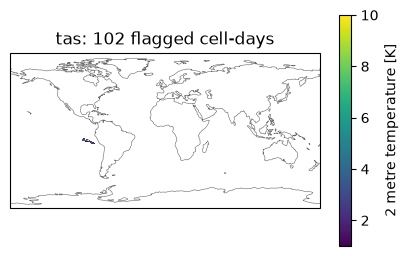

CESM2-WACCM_tasmax_g6_1p5k_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


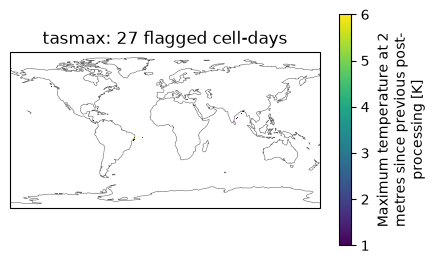

CESM2-WACCM_tasmax_g6_1p5k_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


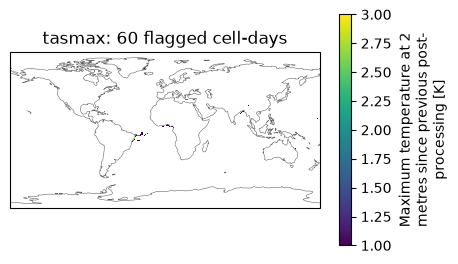

CESM2-WACCM_tasmax_g6_1p5k_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


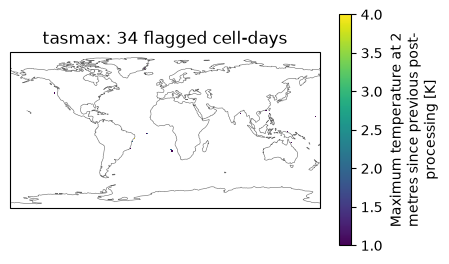

CESM2-WACCM_tasmin_g6_1p5k_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


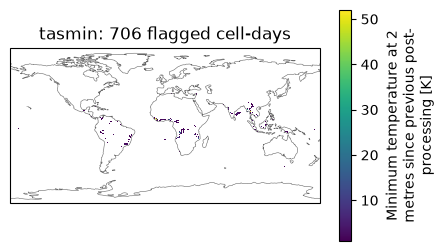

CESM2-WACCM_tasmin_g6_1p5k_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


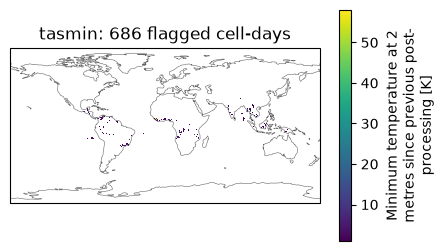

CESM2-WACCM_tasmin_g6_1p5k_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


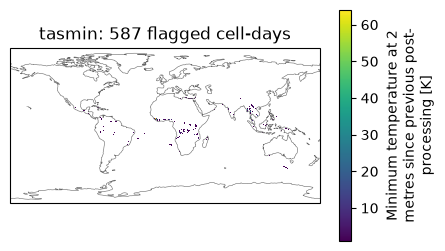

CESM2-WACCM_rsds_historical_r1i1p1f1_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


No flags found.
CESM2-WACCM_rsds_historical_r2i1p1f1_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


No flags found.
CESM2-WACCM_rsds_historical_r3i1p1f1_qdmsd


...

/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


No flags found.
CESM2-WACCM_tasmax_historical_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


No flags found.
CESM2-WACCM_tasmin_historical_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


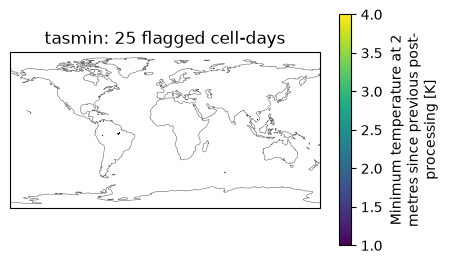

CESM2-WACCM_pr_ssp245_007_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


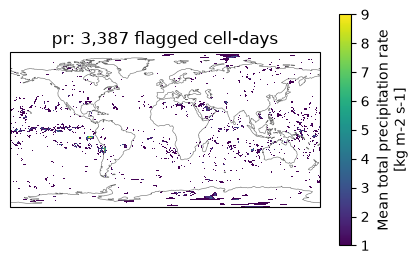

CESM2-WACCM_pr_ssp245_010_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


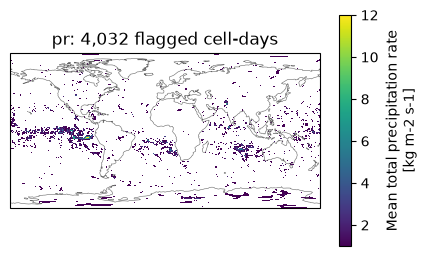

CESM2-WACCM_pr_ssp245_004_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


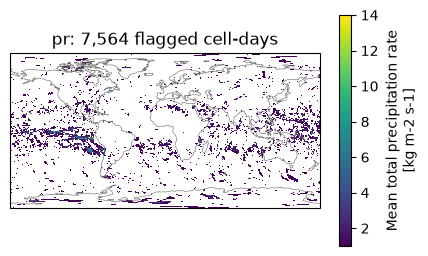

CESM2-WACCM_pr_ssp245_006_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


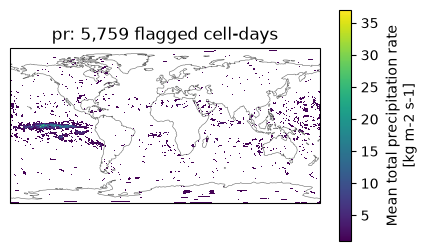

CESM2-WACCM_pr_ssp245_008_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


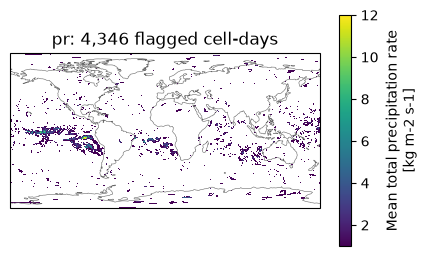

CESM2-WACCM_pr_ssp245_009_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


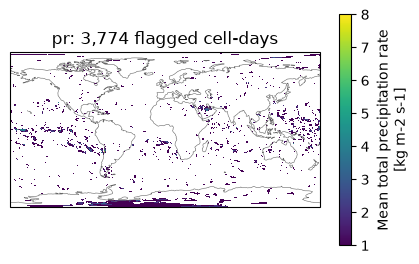

CESM2-WACCM_pr_ssp245_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


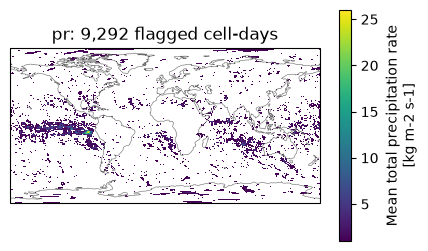

CESM2-WACCM_pr_ssp245_005_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


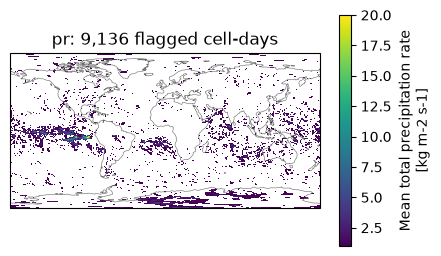

CESM2-WACCM_pr_ssp245_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


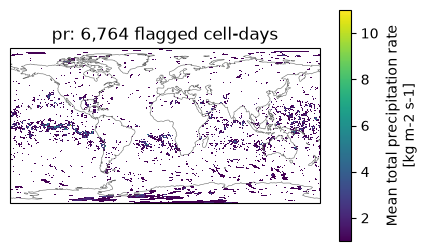

CESM2-WACCM_pr_ssp245_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


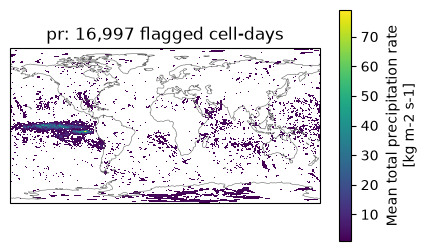

CESM2-WACCM_tas_ssp245_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


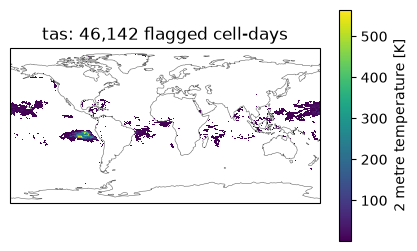

CESM2-WACCM_tas_ssp245_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


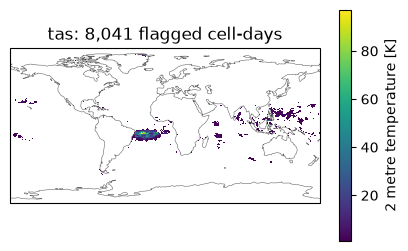

CESM2-WACCM_tas_ssp245_004_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


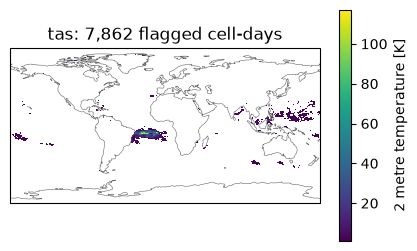

CESM2-WACCM_tas_ssp245_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


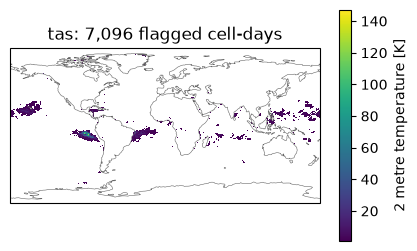

CESM2-WACCM_tas_ssp245_009_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


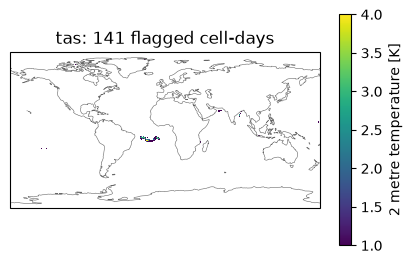

CESM2-WACCM_tas_ssp245_005_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


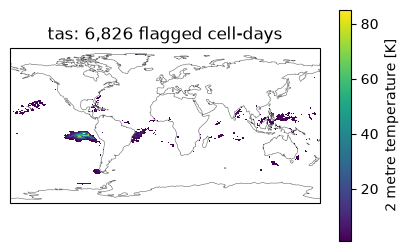

CESM2-WACCM_tas_ssp245_006_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


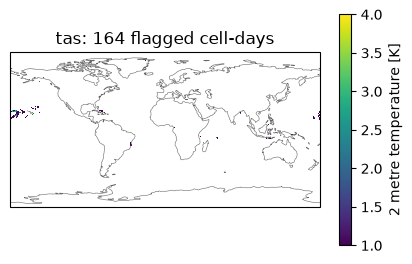

CESM2-WACCM_tas_ssp245_010_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


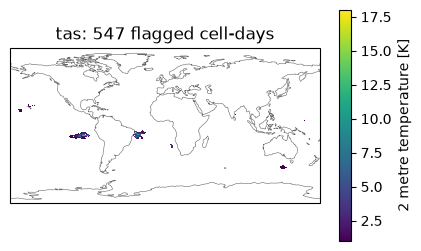

CESM2-WACCM_tas_ssp245_007_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


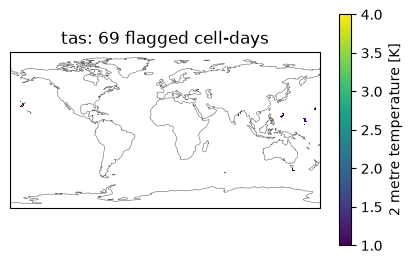

CESM2-WACCM_tas_ssp245_008_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


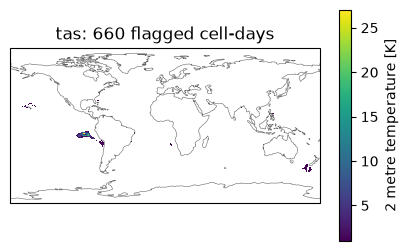

CESM2-WACCM_tasmax_ssp245_008_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


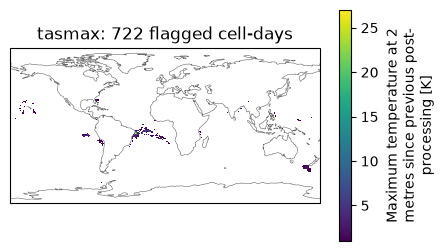

CESM2-WACCM_tasmax_ssp245_010_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


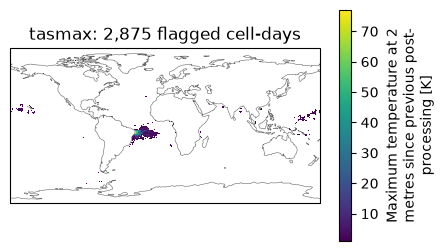

CESM2-WACCM_tasmax_ssp245_006_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


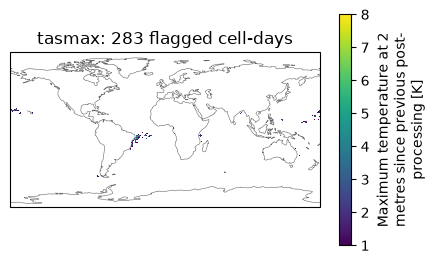

CESM2-WACCM_tasmax_ssp245_009_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


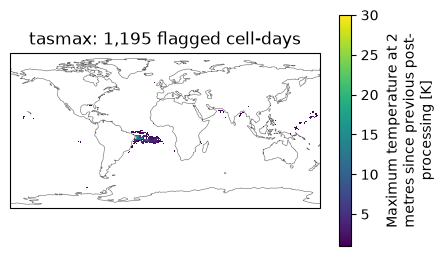

CESM2-WACCM_tasmax_ssp245_007_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


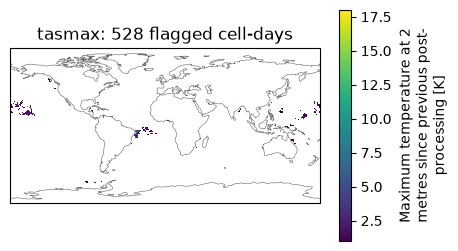

CESM2-WACCM_tasmin_ssp245_008_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


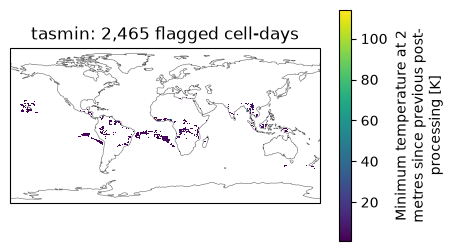

CESM2-WACCM_tasmin_ssp245_006_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


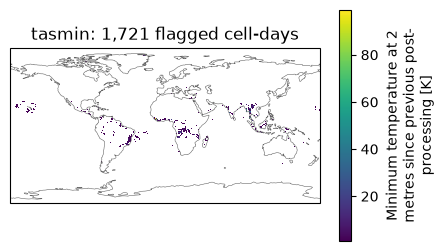

CESM2-WACCM_tasmin_ssp245_007_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


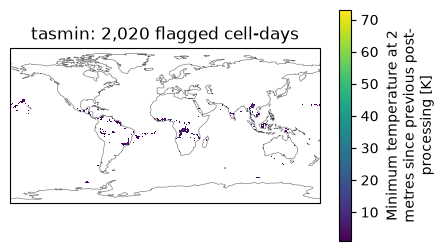

CESM2-WACCM_tasmin_ssp245_010_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


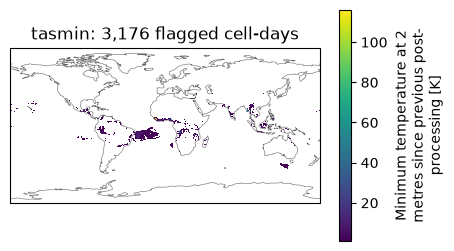

CESM2-WACCM_tasmin_ssp245_009_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


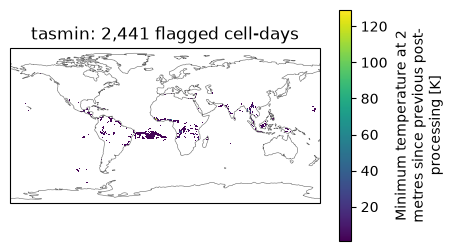

CESM2-WACCM_rsds_ssp245_009_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


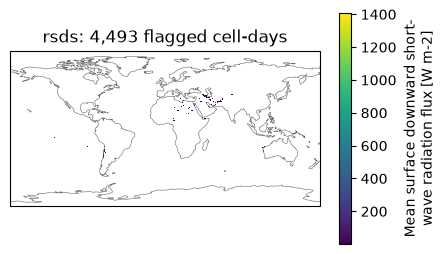

CESM2-WACCM_rsds_ssp245_004_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


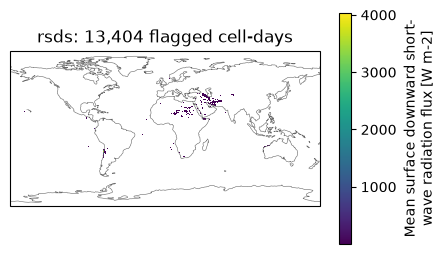

CESM2-WACCM_rsds_ssp245_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


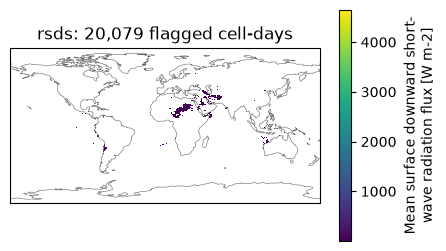

CESM2-WACCM_rsds_ssp245_007_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


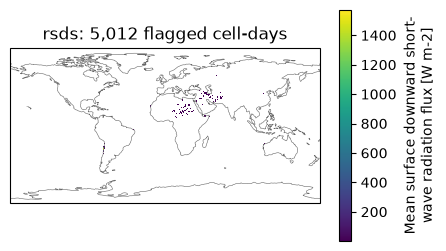

CESM2-WACCM_rsds_ssp245_010_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


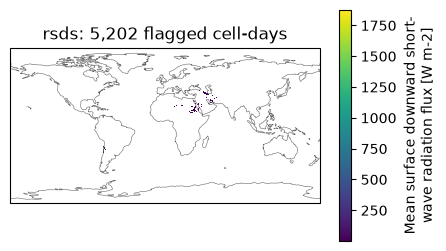

CESM2-WACCM_rsds_ssp245_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


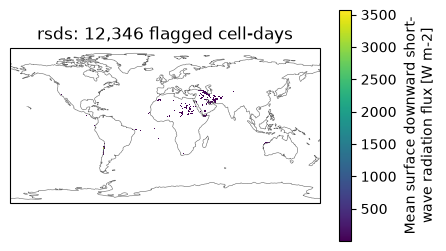

CESM2-WACCM_rsds_ssp245_005_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


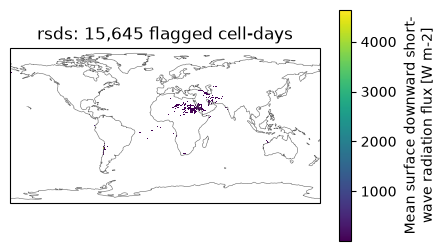

CESM2-WACCM_rsds_ssp245_008_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


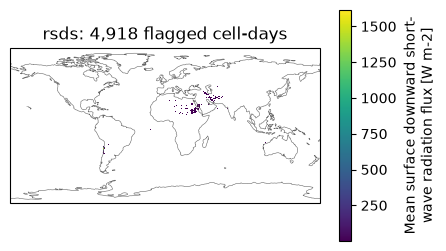

CESM2-WACCM_rsds_ssp245_006_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 21
  result = blockwise(


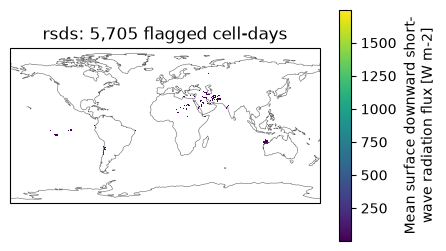

CESM2-WACCM_rsds_ssp245_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


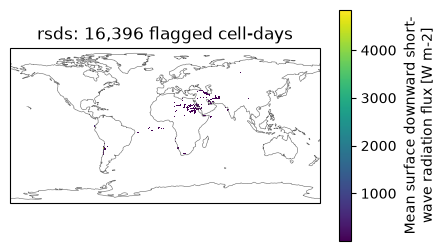

  flag loop 3/5 completed in 447.1s
Running flag loop 4/5: rsds max exceedance flag...
71
CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd


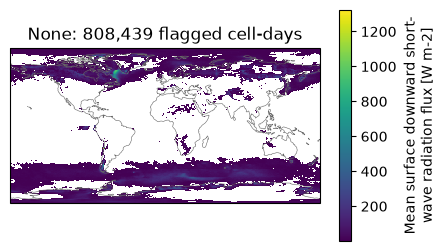

CESM2-WACCM_rsds_g6_1p5k_001_qdmsd


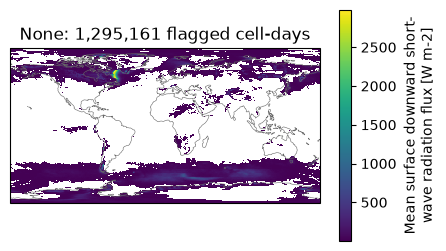

CESM2-WACCM_rsds_g6_1p5k_002_qdmsd


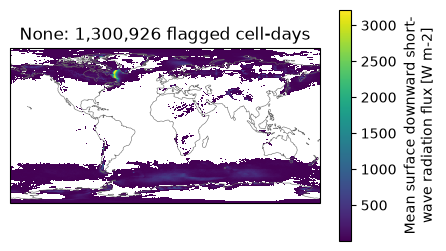

CESM2-WACCM_rsds_g6_1p5k_003_qdmsd


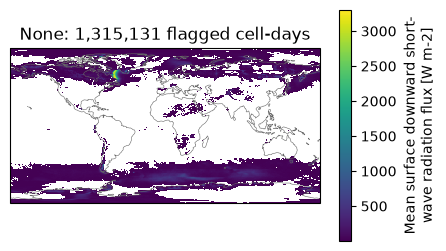

CESM2-WACCM_rsds_historical_r1i1p1f1_qdmsd


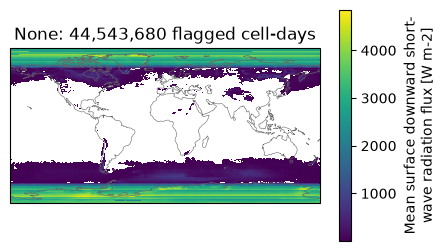

CESM2-WACCM_rsds_historical_r2i1p1f1_qdmsd


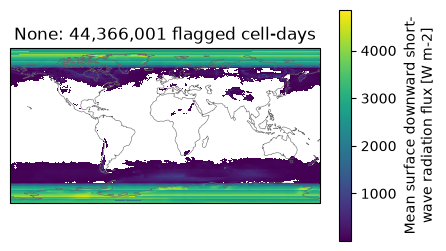

CESM2-WACCM_rsds_historical_r3i1p1f1_qdmsd


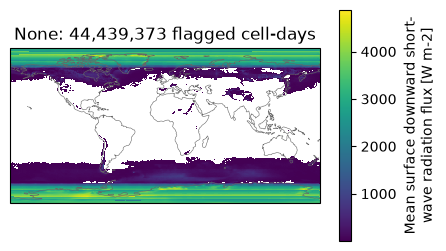

CESM2-WACCM_rsds_ssp245_009_qdmsd


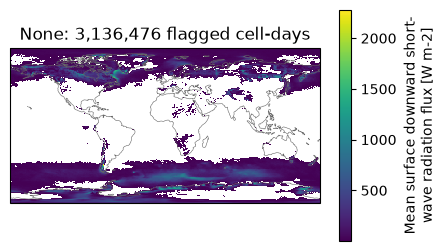

CESM2-WACCM_rsds_ssp245_004_qdmsd


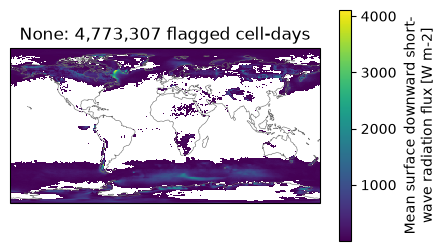

CESM2-WACCM_rsds_ssp245_001_qdmsd


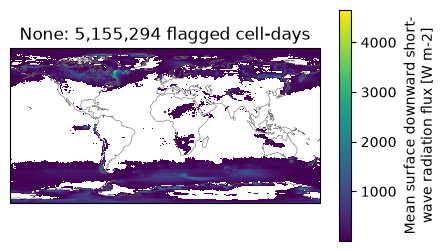

CESM2-WACCM_rsds_ssp245_007_qdmsd


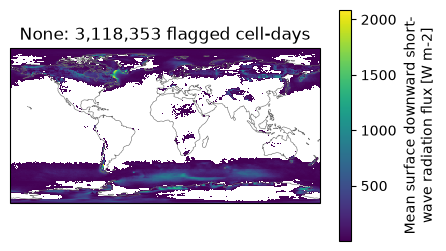

CESM2-WACCM_rsds_ssp245_010_qdmsd


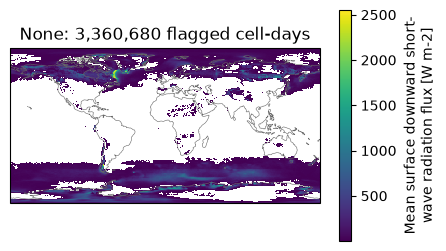

CESM2-WACCM_rsds_ssp245_002_qdmsd


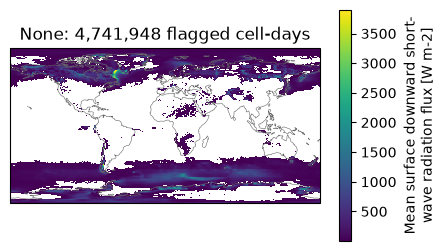

CESM2-WACCM_rsds_ssp245_005_qdmsd


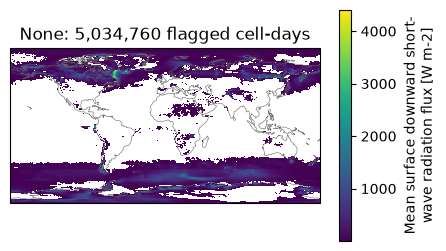

CESM2-WACCM_rsds_ssp245_008_qdmsd


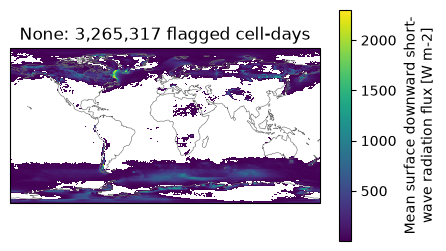

CESM2-WACCM_rsds_ssp245_006_qdmsd


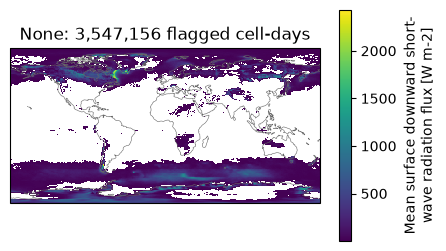

CESM2-WACCM_rsds_ssp245_003_qdmsd


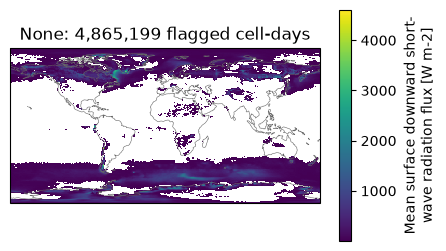

  flag loop 4/5 completed in 137.2s
Running flag loop 5/5: trend distortion flag...
g6_1p5k_ssp245
tas


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:783: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))


No flags found.
No flags found.
CESM2-WACCM_tas_ssp245_001_qdmsd
CESM2-WACCM_tas_ssp245_002_qdmsd
CESM2-WACCM_tas_ssp245_004_qdmsd
CESM2-WACCM_tas_ssp245_003_qdmsd
CESM2-WACCM_tas_ssp245_009_qdmsd
CESM2-WACCM_tas_ssp245_005_qdmsd
CESM2-WACCM_tas_ssp245_006_qdmsd
CESM2-WACCM_tas_ssp245_010_qdmsd
CESM2-WACCM_tas_ssp245_007_qdmsd
CESM2-WACCM_tas_ssp245_008_qdmsd
CESM2-WACCM_tas_g6_1p5k_001_qdmsd
CESM2-WACCM_tas_g6_1p5k_002_qdmsd
CESM2-WACCM_tas_g6_1p5k_003_qdmsd
tasmax


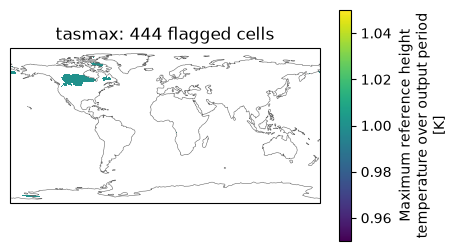

No flags found.
CESM2-WACCM_tasmax_ssp245_008_qdmsd
CESM2-WACCM_tasmax_ssp245_010_qdmsd
CESM2-WACCM_tasmax_ssp245_006_qdmsd
CESM2-WACCM_tasmax_ssp245_009_qdmsd
CESM2-WACCM_tasmax_ssp245_007_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_001_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_003_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_002_qdmsd
tasmin


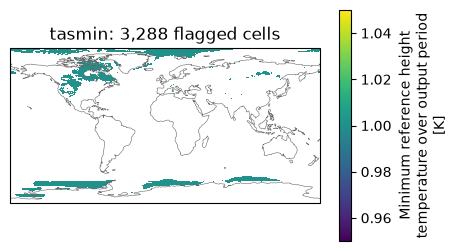

No flags found.
CESM2-WACCM_tasmin_ssp245_008_qdmsd
CESM2-WACCM_tasmin_ssp245_006_qdmsd
CESM2-WACCM_tasmin_ssp245_007_qdmsd
CESM2-WACCM_tasmin_ssp245_010_qdmsd
CESM2-WACCM_tasmin_ssp245_009_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_001_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_003_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_002_qdmsd
pr


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:783: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))


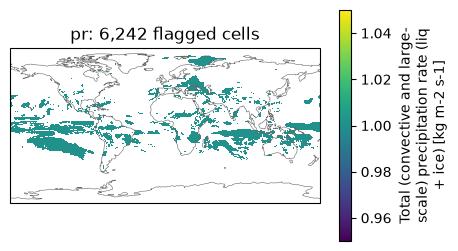

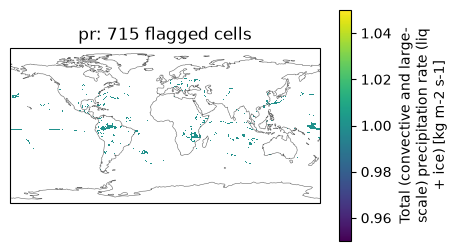

CESM2-WACCM_pr_ssp245_007_qdmsd
CESM2-WACCM_pr_ssp245_010_qdmsd
CESM2-WACCM_pr_ssp245_004_qdmsd
CESM2-WACCM_pr_ssp245_006_qdmsd
CESM2-WACCM_pr_ssp245_008_qdmsd
CESM2-WACCM_pr_ssp245_009_qdmsd
CESM2-WACCM_pr_ssp245_003_qdmsd
CESM2-WACCM_pr_ssp245_005_qdmsd
CESM2-WACCM_pr_ssp245_002_qdmsd
CESM2-WACCM_pr_ssp245_001_qdmsd
CESM2-WACCM_pr_g6_1p5k_001_qdmsd
CESM2-WACCM_pr_g6_1p5k_002_qdmsd
CESM2-WACCM_pr_g6_1p5k_003_qdmsd
rsds


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:783: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario1 = xr.concat(das_scenario1, dim=pd.Index(ens_scenario1, name="ensemble_member"))


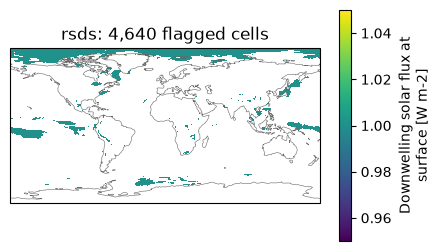

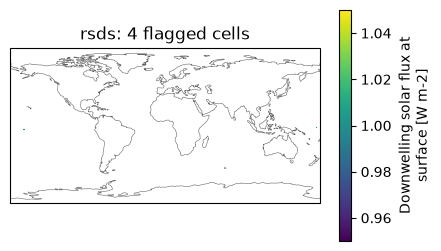

CESM2-WACCM_rsds_ssp245_009_qdmsd
CESM2-WACCM_rsds_ssp245_004_qdmsd
CESM2-WACCM_rsds_ssp245_001_qdmsd
CESM2-WACCM_rsds_ssp245_007_qdmsd
CESM2-WACCM_rsds_ssp245_010_qdmsd
CESM2-WACCM_rsds_ssp245_002_qdmsd
CESM2-WACCM_rsds_ssp245_005_qdmsd
CESM2-WACCM_rsds_ssp245_008_qdmsd
CESM2-WACCM_rsds_ssp245_006_qdmsd
CESM2-WACCM_rsds_ssp245_003_qdmsd
CESM2-WACCM_rsds_g6_1p5k_001_qdmsd
CESM2-WACCM_rsds_g6_1p5k_002_qdmsd
CESM2-WACCM_rsds_g6_1p5k_003_qdmsd
ssp245_hist
tas


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:796: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))


No flags found.
No flags found.
CESM2-WACCM_tas_historical_r1i1p1f1_qdmsd
CESM2-WACCM_tas_historical_r3i1p1f1_qdmsd
CESM2-WACCM_tas_historical_r2i1p1f1_qdmsd
CESM2-WACCM_tas_ssp245_001_qdmsd
CESM2-WACCM_tas_ssp245_002_qdmsd
CESM2-WACCM_tas_ssp245_004_qdmsd
CESM2-WACCM_tas_ssp245_003_qdmsd
CESM2-WACCM_tas_ssp245_009_qdmsd
CESM2-WACCM_tas_ssp245_005_qdmsd
CESM2-WACCM_tas_ssp245_006_qdmsd
CESM2-WACCM_tas_ssp245_010_qdmsd
CESM2-WACCM_tas_ssp245_007_qdmsd
CESM2-WACCM_tas_ssp245_008_qdmsd
tasmax


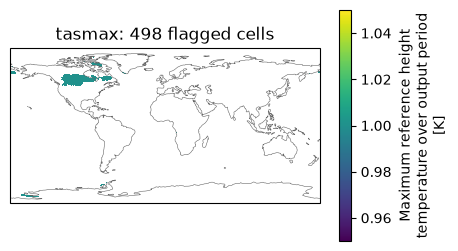

No flags found.
CESM2-WACCM_tasmax_historical_001_qdmsd
CESM2-WACCM_tasmax_ssp245_008_qdmsd
CESM2-WACCM_tasmax_ssp245_010_qdmsd
CESM2-WACCM_tasmax_ssp245_006_qdmsd
CESM2-WACCM_tasmax_ssp245_009_qdmsd
CESM2-WACCM_tasmax_ssp245_007_qdmsd
tasmin


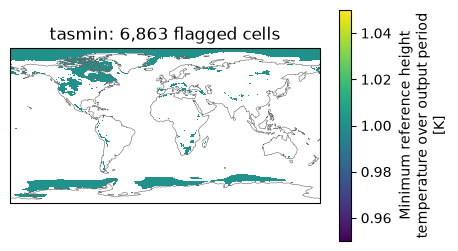

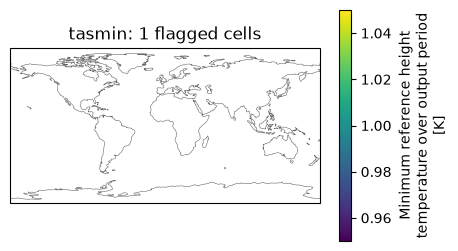

CESM2-WACCM_tasmin_historical_001_qdmsd
CESM2-WACCM_tasmin_ssp245_008_qdmsd
CESM2-WACCM_tasmin_ssp245_006_qdmsd
CESM2-WACCM_tasmin_ssp245_007_qdmsd
CESM2-WACCM_tasmin_ssp245_010_qdmsd
CESM2-WACCM_tasmin_ssp245_009_qdmsd
pr


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:796: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))


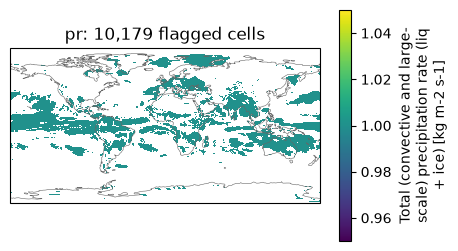

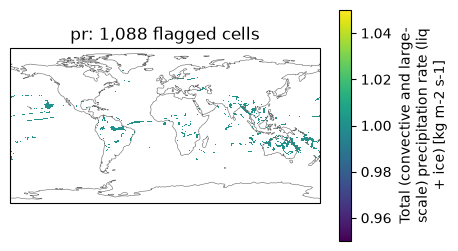

CESM2-WACCM_pr_historical_r1i1p1f1_qdmsd
CESM2-WACCM_pr_historical_r3i1p1f1_qdmsd
CESM2-WACCM_pr_historical_r2i1p1f1_qdmsd
CESM2-WACCM_pr_ssp245_007_qdmsd
CESM2-WACCM_pr_ssp245_010_qdmsd
CESM2-WACCM_pr_ssp245_004_qdmsd
CESM2-WACCM_pr_ssp245_006_qdmsd
CESM2-WACCM_pr_ssp245_008_qdmsd
CESM2-WACCM_pr_ssp245_009_qdmsd
CESM2-WACCM_pr_ssp245_003_qdmsd
CESM2-WACCM_pr_ssp245_005_qdmsd
CESM2-WACCM_pr_ssp245_002_qdmsd
CESM2-WACCM_pr_ssp245_001_qdmsd
rsds


/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_95431/506929659.py:796: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  var_scenario2 = xr.concat(das_scenario2, dim=pd.Index(ens_scenario2, name="ensemble_member"))


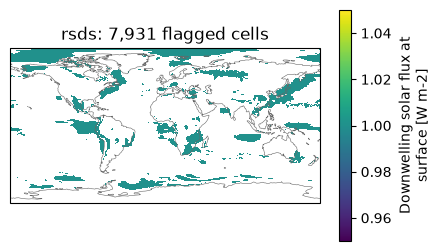

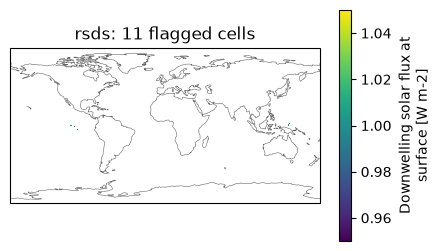

CESM2-WACCM_rsds_historical_r1i1p1f1_qdmsd
CESM2-WACCM_rsds_historical_r2i1p1f1_qdmsd
CESM2-WACCM_rsds_historical_r3i1p1f1_qdmsd
CESM2-WACCM_rsds_ssp245_009_qdmsd
CESM2-WACCM_rsds_ssp245_004_qdmsd
CESM2-WACCM_rsds_ssp245_001_qdmsd
CESM2-WACCM_rsds_ssp245_007_qdmsd
CESM2-WACCM_rsds_ssp245_010_qdmsd
CESM2-WACCM_rsds_ssp245_002_qdmsd
CESM2-WACCM_rsds_ssp245_005_qdmsd
CESM2-WACCM_rsds_ssp245_008_qdmsd
CESM2-WACCM_rsds_ssp245_006_qdmsd
CESM2-WACCM_rsds_ssp245_003_qdmsd
g6_1p5k_hist
tas
No flags found.
No flags found.
CESM2-WACCM_tas_historical_r1i1p1f1_qdmsd
CESM2-WACCM_tas_historical_r3i1p1f1_qdmsd
CESM2-WACCM_tas_historical_r2i1p1f1_qdmsd
CESM2-WACCM_tas_g6_1p5k_001_qdmsd
CESM2-WACCM_tas_g6_1p5k_002_qdmsd
CESM2-WACCM_tas_g6_1p5k_003_qdmsd
tasmax
No flags found.
No flags found.
CESM2-WACCM_tasmax_historical_001_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_001_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_003_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_002_qdmsd
tasmin


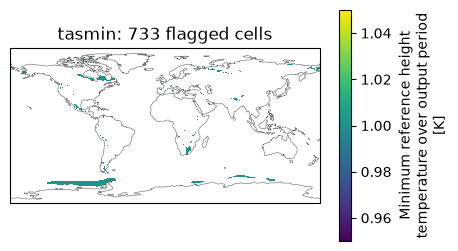

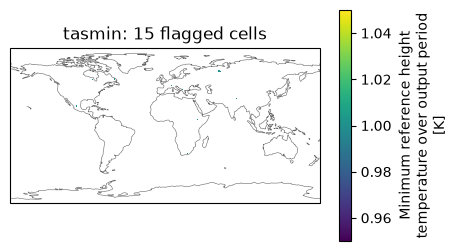

CESM2-WACCM_tasmin_historical_001_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_001_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_003_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_002_qdmsd
pr


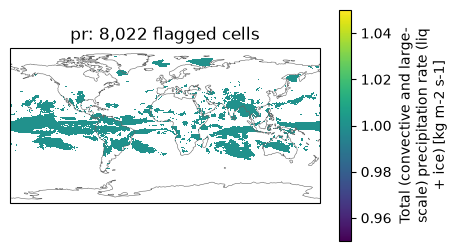

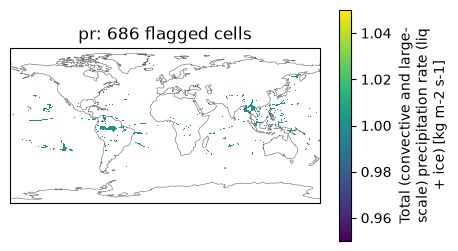

CESM2-WACCM_pr_historical_r1i1p1f1_qdmsd
CESM2-WACCM_pr_historical_r3i1p1f1_qdmsd
CESM2-WACCM_pr_historical_r2i1p1f1_qdmsd
CESM2-WACCM_pr_g6_1p5k_001_qdmsd
CESM2-WACCM_pr_g6_1p5k_002_qdmsd
CESM2-WACCM_pr_g6_1p5k_003_qdmsd
rsds


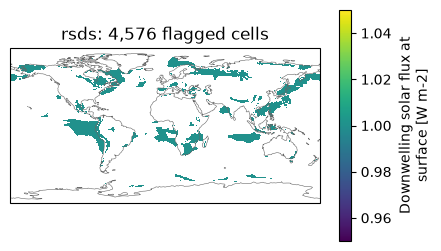

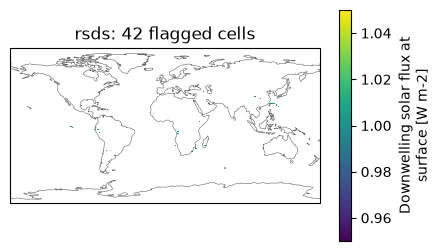

CESM2-WACCM_rsds_historical_r1i1p1f1_qdmsd
CESM2-WACCM_rsds_historical_r2i1p1f1_qdmsd
CESM2-WACCM_rsds_historical_r3i1p1f1_qdmsd
CESM2-WACCM_rsds_g6_1p5k_001_qdmsd
CESM2-WACCM_rsds_g6_1p5k_002_qdmsd
CESM2-WACCM_rsds_g6_1p5k_003_qdmsd
g6_1p5k_end_g6_1p5k
tas


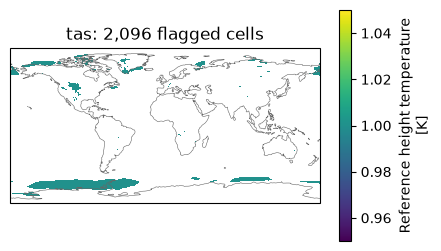

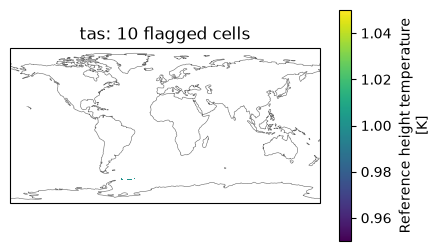

CESM2-WACCM_tas_g6_1p5k_001_qdmsd
CESM2-WACCM_tas_g6_1p5k_002_qdmsd
CESM2-WACCM_tas_g6_1p5k_003_qdmsd
CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd
tasmax


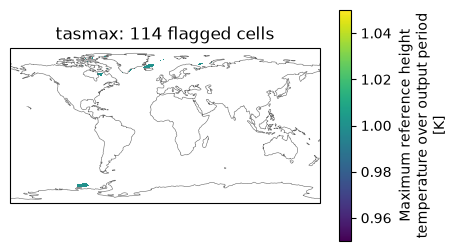

No flags found.
CESM2-WACCM_tasmax_g6_1p5k_001_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_003_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_002_qdmsd
CESM2-WACCM_tasmax_g6_1p5k_end_002_qdmsd
tasmin


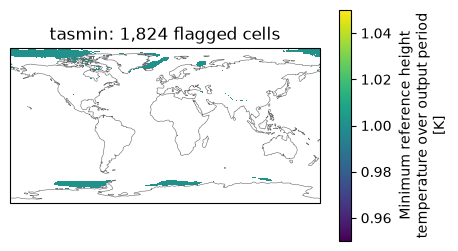

No flags found.
CESM2-WACCM_tasmin_g6_1p5k_001_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_003_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_002_qdmsd
CESM2-WACCM_tasmin_g6_1p5k_end_002_qdmsd
pr


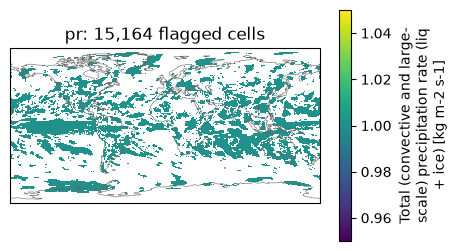

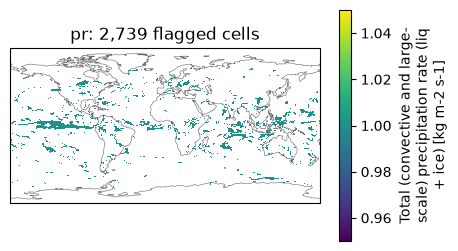

CESM2-WACCM_pr_g6_1p5k_001_qdmsd
CESM2-WACCM_pr_g6_1p5k_002_qdmsd
CESM2-WACCM_pr_g6_1p5k_003_qdmsd
CESM2-WACCM_pr_g6_1p5k_end_002_qdmsd
rsds


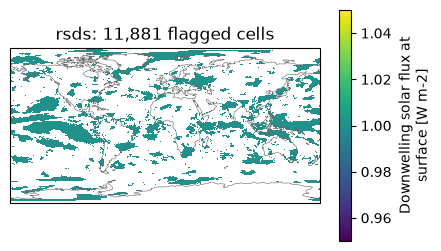

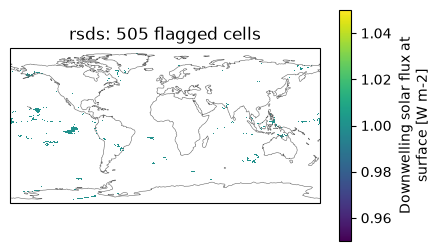

CESM2-WACCM_rsds_g6_1p5k_001_qdmsd
CESM2-WACCM_rsds_g6_1p5k_002_qdmsd
CESM2-WACCM_rsds_g6_1p5k_003_qdmsd
CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd
  flag loop 5/5 completed in 2016.9s
calculate_all_flags total time: 3129.6s
  flags on coarse debiased data for CESM2-WACCM completed in 3129.6s
  flags on coarse debiased data (all gcms) completed in 3129.6s
run_step2 total time: 3205.9s


In [8]:
run_step2(
    variables=VARIABLES,
    gcms=GCMS,
    methods=["qdmsd"],
    branch=BRANCH,
    root_dir=ROOT_DIR,
    store_subset_id=STORE_SUBSET_ID,
    bucket=BUCKET,
    prefix=PREFIX,
    plot_flag_maps=True,
    verbose=True,
    mode="debiased_coarse_only",
)

In [12]:
cluster.shutdown()

[2026-09-06 13:11:57,128][INFO    ][coiled] Cluster 2013957 deleted successfully.


# Run through all flag calculations with single loop

Running flag loop 1/5: global exceedance flag...
71
CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_end_002_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_003_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_001_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_002_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_004_qdmsd


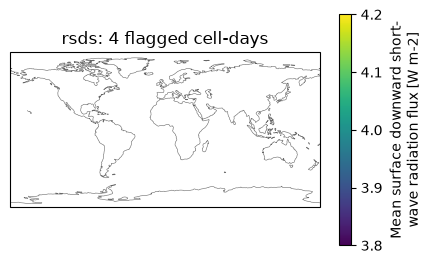

CESM2-WACCM_rsds_ssp245_005_qdmsd


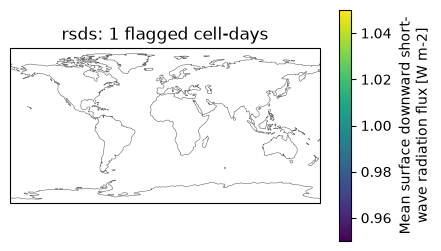

CESM2-WACCM_rsds_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_rsds_ssp245_009_qdmsd


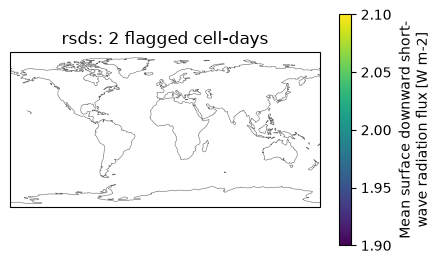

CESM2-WACCM_tasmax_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_009_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_tasmax_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_001_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_005_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_009_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_003_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_004_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_006_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_pr_ssp245_002_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_008_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_005_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_007_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_010_qdmsd
No flags found.
CESM2-WACCM_tas_ssp245_002_qdmsd
No flags found.
CESM2-WACCM_tas

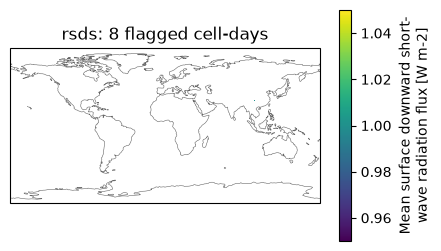

CESM2-WACCM_rsds_g6_1p5k_002_qdmsd


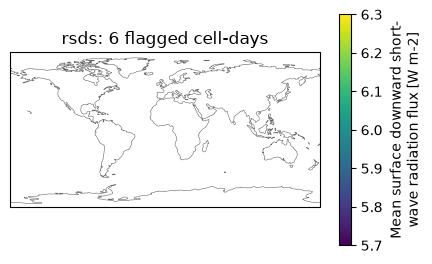

CESM2-WACCM_rsds_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tasmin_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_pr_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_002_qdmsd
No flags found.
CESM2-WACCM_tasmax_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_001_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_003_qdmsd
No flags found.
CESM2-WACCM_tas_g6_1p5k_002_qdmsd
No flags found.
  flag loop 1/5 completed in 1748.5s
Running flag loop 2/5: temperature inconsistency flag...
71
CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd


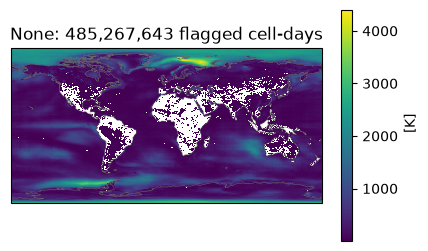

CESM2-WACCM_tas_ssp245_008_qdmsd


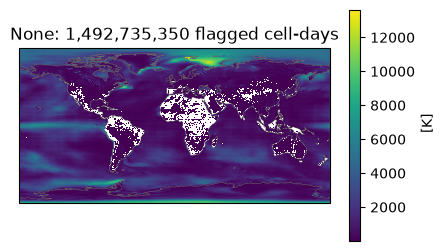

CESM2-WACCM_tas_ssp245_007_qdmsd


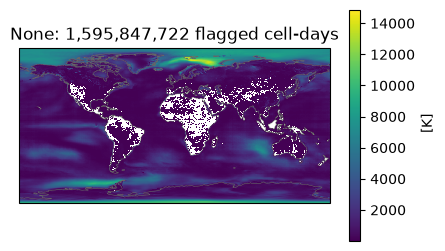

CESM2-WACCM_tas_ssp245_010_qdmsd


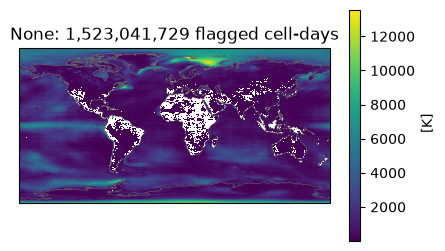

CESM2-WACCM_tas_ssp245_009_qdmsd


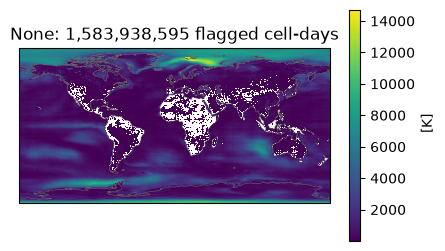

CESM2-WACCM_tas_ssp245_006_qdmsd


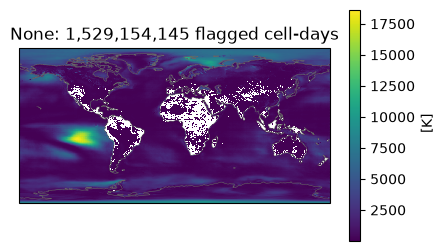

CESM2-WACCM_tas_g6_1p5k_001_qdmsd


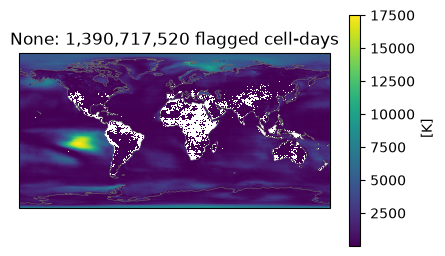

CESM2-WACCM_tas_g6_1p5k_003_qdmsd


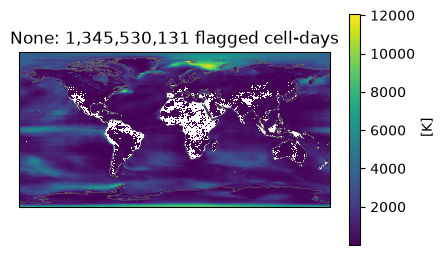

CESM2-WACCM_tas_g6_1p5k_002_qdmsd


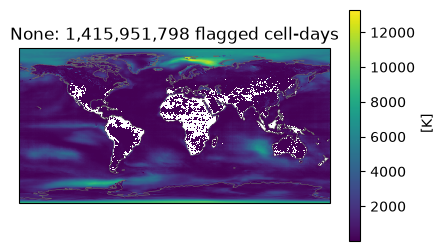

  flag loop 2/5 completed in 923.3s
Running flag loop 3/5: annual outlier flag...
71
CESM2-WACCM_tas_g6_1p5k_end_002_qdmsd


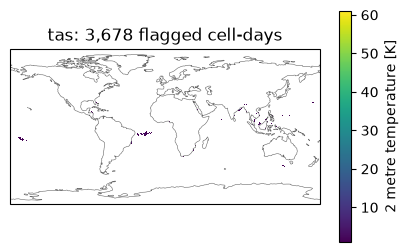

CESM2-WACCM_pr_g6_1p5k_end_002_qdmsd


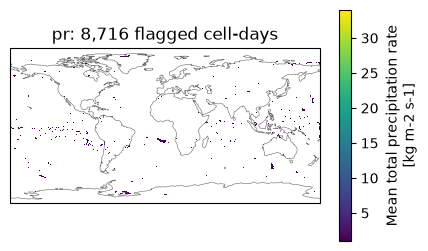

CESM2-WACCM_tasmax_g6_1p5k_end_002_qdmsd


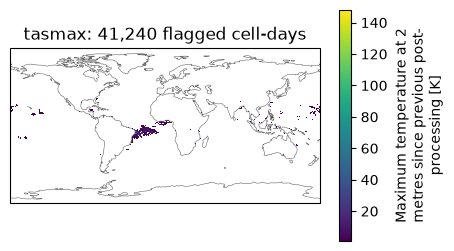

CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd


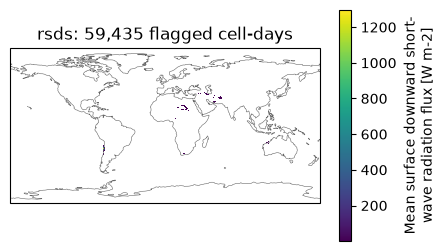

CESM2-WACCM_tasmin_g6_1p5k_end_002_qdmsd


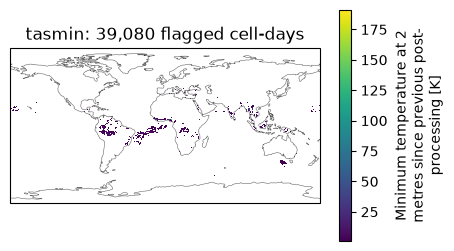

CESM2-WACCM_rsds_ssp245_007_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(


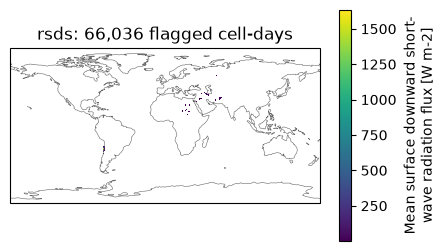

CESM2-WACCM_rsds_ssp245_008_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(


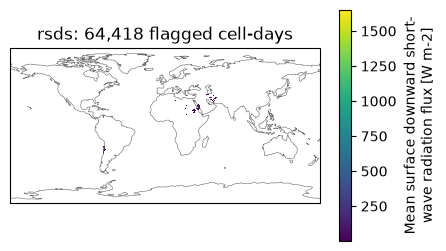

CESM2-WACCM_rsds_ssp245_006_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(


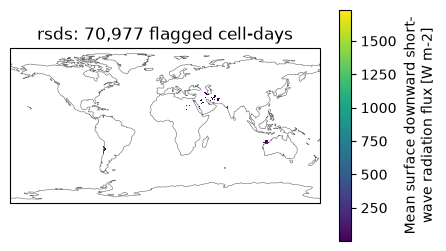

CESM2-WACCM_rsds_ssp245_003_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 35
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 35
  result = blockwise(


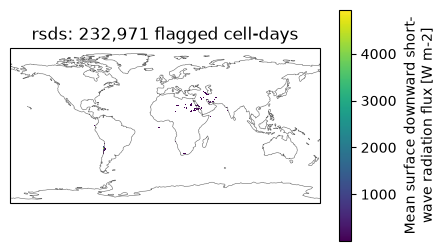

CESM2-WACCM_rsds_ssp245_001_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 35
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 35
  result = blockwise(


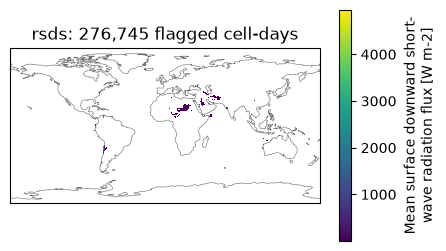

CESM2-WACCM_rsds_ssp245_002_qdmsd


/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 35
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 35
  result = blockwise(


In [ ]:
from srm.qa_flags import calculate_all_flags

calculate_all_flags(
    variables=VARIABLES,
    gcms=GCMS,
    methods=["qdmsd"],
    bucket=BUCKET,
    prefix=PREFIX,
    trees=trees,
    tags=tags,
    gcms_np=gcms_np,
    scenarios_np=scenarios_np,
    variables_np=variables_np,
    tags_np=tags_np,
    methods_np=methods_np,
    plot_flag_maps=True,
    grid_type="downscaled",
    verbose=True,
)

# B. Generate individual time-varying QA flags

## 1. global exceedances

In [ ]:
%%time
run_flag_loop(
    tags=tags,
    trees=trees,
    bucket=BUCKET,
    prefix=PREFIX,
    flag_name="outside_global_plausible_range",
    compute_flag=lambda da, var: flag_global_exceedances(da=da, var=var),
    write_mode="a",
)

# with plotting ~14.5 mins

## 2. Outliers based on observations

### 2a. Calculate outlier bounds

In [ ]:
# Loading thresholds output from step 1 notebook
store = DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr"
combined = xr.open_zarr(store)

In [ ]:
def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

In [ ]:
[outlier_thresh_low, outlier_thresh_high] = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)

### 2b. Traverse dataset and save flags

In [ ]:
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")

In [ ]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="annual_outlier_flag",
    compute_flag=lambda da, var: flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual[var],
        outlier_thresh_high=outlier_thresh_high_annual[var],
        timescale="annual",
    ),
    bucket=BUCKET,
    prefix=PREFIX,
    write_mode="a",
)

## 3. rsds-specific latitude check

In [ ]:
def load_rsds_lims(
    key: str = "zonal_doy_max_rsds",
    fpath: str = DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr",
) -> xr.DataArray:
    return xr.open_zarr(fpath, group=key)["data"].load()

In [ ]:
zonal_doy_max_rsds = load_rsds_lims()

In [ ]:
run_flag_loop(
    tags=tags,
    trees=trees,
    flag_name="rsds_max_exceeded",
    compute_flag=lambda da, var: flag_rsds_above_max(da=da, zonal_doy_max_rsds=zonal_doy_max_rsds),
    var_filter="rsds",
    bucket=BUCKET,
    prefix=PREFIX,
    write_mode="a",
)

## 4. temperature inconsistencies

In [ ]:
from srm.qa_flags import flag_tasmax_tas_inconsistency, flag_tasmin_tas_inconsistency

In [ ]:
# This could be modified to fit within the run_flag_loop structure

var_filter = "tas"
plot = True

print(len(tags))
for tag in tags:
    gcm, var, scenario, ens, method = parse_tag(tag)
    if var_filter is not None and var != var_filter:
        continue

    tag_tasmin = f"{gcm}_tasmin_{scenario}_{ens}_{method}"
    tag_tasmax = f"{gcm}_tasmax_{scenario}_{ens}_{method}"
    if (tag_tasmin in tags) and (tag_tasmax in tags):
        print(tag)

        tas = get_data(tag=tag, trees=trees)
        tasmin = get_data(tag=tag_tasmin, trees=trees)
        tasmax = get_data(tag=tag_tasmax, trees=trees)

        flag_tas_tasmax = flag_tasmax_tas_inconsistency(tas, tasmax)
        flag_tas_tasmin = flag_tasmin_tas_inconsistency(tas, tasmin)

        flag_tas = (flag_tas_tasmax + flag_tas_tasmin) > 0
        flag_tasmin = flag_tas_tasmin
        flag_tasmax = flag_tas_tasmax

        write_individual_flags(
            flag_data=flag_tas,
            flag_name="temperature_inconsistency",
            tag=tag,
            write_mode="a",
            bucket=BUCKET,
            prefix=PREFIX,
        )

        write_individual_flags(
            flag_data=flag_tasmax,
            flag_name="temperature_inconsistency",
            tag=tag,
            write_mode="a",
            bucket=BUCKET,
            prefix=PREFIX,
        )

        write_individual_flags(
            flag_data=flag_tasmin,
            flag_name="temperature_inconsistency",
            tag=tag,
            write_mode="a",
            bucket=BUCKET,
            prefix=PREFIX,
        )

        if plot:
            plot_flags(flags=flag_tas, time_varying=True, separate_low_high=False)
            plt.show()
            plt.close()

# C. Generate flags that are constant over time

In [ ]:
from srm.qa_flags import (
    SCENARIO_COMPARISONS as scenario_comparisons,
    TREND_VARIABLE_SETTINGS as VARIABLE_SETTINGS,
    calculate_ensemble_mean_deltas,
)

In [ ]:
plot = True
for key in scenario_comparisons:
    print(key)
    comparison_dict = scenario_comparisons[key]
    scenario1 = comparison_dict["scenario1"]
    scenario2 = comparison_dict["scenario2"]
    scenario1_time_slice = comparison_dict["scenario1_time_slice"]
    scenario2_time_slice = comparison_dict["scenario2_time_slice"]

    for gcm in GCMS:
        for var in VARIABLES:
            print(var)
            # Find tags to use in scenario comparison (all ensemble members for this variable and gcm for the two comparison scenarios)
            tags_scenario1 = tags_np[
                (gcms_np == gcm) * (scenarios_np == scenario1) * (variables_np == var)
            ]
            tags_scenario2 = tags_np[
                (gcms_np == gcm) * (scenarios_np == scenario2) * (variables_np == var)
            ]

            # Calculate distortions
            [delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds] = (
                calculate_ensemble_mean_deltas(
                    variable=var,
                    tags_scenario1=tags_scenario1,
                    tags_scenario2=tags_scenario2,
                    gcm=gcm,
                    scenario1=scenario1,
                    scenario2=scenario2,
                    scenario1_time_slice=scenario1_time_slice,
                    scenario2_time_slice=scenario2_time_slice,
                    trees=trees,
                )
            )

            distortion_absolute = delta_ds_coarse - delta_raw
            distortion_pct = delta_ds_coarse_pct - delta_raw_pct

            # Flag distortions at coarse scale
            abs_tol = VARIABLE_SETTINGS[var]["abs_tol"]
            pct_tol = VARIABLE_SETTINGS[var]["pct_tol"]
            sign_flip_tol = VARIABLE_SETTINGS[var]["sign_flip"]
            scale = VARIABLE_SETTINGS[var]["scale"]

            trend_distortion_flag = calculate_distortion_flags(
                distortion_absolute=distortion_absolute * scale,
                distortion_pct=distortion_pct,
                tolerance_absolute=abs_tol,
                tolerance_pct=pct_tol,
            )

            flipped_sign_flag = sign_flip_mask(
                delta_ds_coarse * scale, delta_raw * scale, threshold=sign_flip_tol
            )

            # Propagate coarse distortion flags to fine scale
            trend_distortion_flag_fine_frac = interpolate_coarse_to_fine_grid(
                da_coarse_to_regrid=trend_distortion_flag.astype("float32"), da_fine_grid=delta_ds
            )
            trend_distortion_flag_fine = trend_distortion_flag_fine_frac > 0

            flipped_sign_flag_fine_frac = interpolate_coarse_to_fine_grid(
                da_coarse_to_regrid=flipped_sign_flag.astype("float32"), da_fine_grid=delta_ds
            )
            flipped_sign_flag_fine = flipped_sign_flag_fine_frac > 0

            if plot:
                plot_flags(
                    flags=trend_distortion_flag_fine, time_varying=False, separate_low_high=False
                )
                plt.show()
                plt.close()

                plot_flags(
                    flags=flipped_sign_flag_fine, time_varying=False, separate_low_high=False
                )
                plt.show()
                plt.close()

            # Write out flags
            tags_to_flag = np.concat([tags_scenario1, tags_scenario2])
            for tag in tags_to_flag:
                print(tag)
                gcm, var, scenario, ens, method = parse_tag(tag)
                write_individual_flags(
                    flag_data=trend_distortion_flag_fine,
                    flag_name="trend_distortion_" + scenario1 + "_" + scenario2,
                    tag=tag,
                    write_mode="a",
                    bucket=BUCKET,
                    prefix=PREFIX,
                )

                write_individual_flags(
                    flag_data=flipped_sign_flag_fine,
                    flag_name="flipped_sign_" + scenario1 + "_" + scenario2,
                    tag=tag,
                    write_mode="a",
                    bucket=BUCKET,
                    prefix=PREFIX,
                )

In [ ]:
if cluster is not None:
    cluster.shutdown()
else:
    print("no cluster was created (cached run); nothing to shut down")

# D. Read in flags

In [ ]:
from srm.qa_flags import get_intermediate_flags

gcm = "CESM2-WACCM"
var = "rsds"
scenario = "ssp245"
ens = "008"
method = "qdmsd"

tag = f"{gcm}_{var}_{scenario}_{ens}_{method}"
flag_ds = get_intermediate_flags(tag=tag, bucket=BUCKET, prefix=PREFIX)

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2)
flag_frac = flag_ds["outside_global_plausible_range"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 0])
flag_frac = flag_ds["rsds_max_exceeded"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[0, 1])
flag_frac = flag_ds["annual_outlier_flag"].mean(dim="time")
flag_frac.where(flag_frac > 0).plot(ax=axes[1, 0])
plt.tight_layout()

In [ ]:
flag_ds["rsds_max_exceeded"].sum(dim="time").plot()
plt.plot([28.5], [-29.6], "xr")